# Crop-based Classifier — Sensitivity Analysis

Three analyses on the **group classifier** (InsectNet, `4group_insectnet.pth`) across **all four classes**.

**Data source**: ground-truth crops extracted from the independent evaluation set (`data/evaluation/`), using YOLO-format annotations. These images were **never used for training**.

| Class | GT crops | Note |
|---|---|---|
| bumblebee | ~24 | Small sample — interpret with caution |
| fly | ~602 | Main class — results most reliable |
| butterfly | ~4 | Very small — indicative only |
| other | ~117 | Reasonable |

| Analysis | What it shows |
|---|---|
| **GradCAM** | Which image regions drive each class prediction |
| **Robustness** | Per-class recall under blur / darkness / JPEG compression |
| **ECE** | Whether model confidence scores are well-calibrated (all classes) |

##### Cell 1 — Environment  *(no edits needed)*

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')

import sys
import subprocess
from pathlib import Path

_git_root = Path(subprocess.check_output(
    ['git', 'rev-parse', '--show-toplevel'], text=True).strip())
BASE_DIR  = _git_root / 'ml_pipelines' / 'notebooks' / 'pollinator_detection'

MODEL_DIR   = BASE_DIR / 'models'
EVAL_ANNOT  = BASE_DIR / 'data' / 'evaluation' / 'annotations'
EVAL_IMAGES = BASE_DIR / 'data' / 'evaluation' / 'images'

print(f'BASE_DIR   : {BASE_DIR}  exists={BASE_DIR.exists()}')
print(f'MODEL_DIR  : {MODEL_DIR}  exists={MODEL_DIR.exists()}')
print(f'EVAL_ANNOT : {EVAL_ANNOT}  exists={EVAL_ANNOT.exists()}')
print(f'EVAL_IMAGES: {EVAL_IMAGES}  exists={EVAL_IMAGES.exists()}')

BASE_DIR   : /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection  exists=True
MODEL_DIR  : /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/models  exists=True
EVAL_ANNOT : /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/data/evaluation/annotations  exists=True
EVAL_IMAGES: /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/data/evaluation/images  exists=True


##### Cell 2 — Imports

In [2]:
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

sys.path.insert(0, str(_git_root))
from ml_pipelines.pollinator.training.backbones import build_insectnet, load_checkpoint
from ml_pipelines.pollinator.training.datasets import letterbox

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


##### Cell 3 — Config

In [3]:
GROUP_CKPT = MODEL_DIR / '4group_insectnet.pth'
IMG_SIZE   = 224
SEED       = 42

# Group classifier class order (must match training)
CLASSES = ['bumblebee', 'fly', 'butterfly', 'other']

# GT annotation class IDs match the group classifier indices 0-3
GT_CLASS_IDS = {cls: i for i, cls in enumerate(CLASSES)}

COLORS = {
    'bumblebee': '#E69F00',
    'fly':       '#56B4E9',
    'butterfly': '#009E73',
    'other':     '#CC79A7',
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Output directory ────────────────────────────────────────────────────────
import datetime as _dt
_ts    = _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
OUT_DIR = BASE_DIR / 'outputs' / 'evaluation' / f'crop_sensitivity_{_ts}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir → {OUT_DIR}')


##### Cell 4 — Load model and extract GT crops for all classes

In [4]:
# Model
model, _ = build_insectnet(None, num_classes=len(CLASSES), unfreeze_last_block=True)
load_checkpoint(model, str(GROUP_CKPT), device='cpu')
model = model.to(DEVICE).eval()
print(f'Loaded: {GROUP_CKPT.name}')

def extract_gt_crops(annot_root, image_root, class_id):
    crops = []
    for scene_dir in sorted(annot_root.iterdir()):
        obj_dir = scene_dir / 'obj_train_data'
        img_dir = image_root / scene_dir.name
        if not obj_dir.exists() or not img_dir.exists():
            continue
        for txt_file in sorted(obj_dir.glob('*.txt')):
            stem = txt_file.stem
            img_path = None
            for ext in ('.JPG', '.jpg', '.jpeg', '.png', '.PNG'):
                c = img_dir / (stem + ext)
                if c.exists():
                    img_path = c
                    break
            if img_path is None:
                continue
            img = Image.open(img_path).convert('RGB')
            W, H = img.size
            for line in txt_file.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5 or int(parts[0]) != class_id:
                    continue
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = max(0, int((cx - bw/2) * W))
                y1 = max(0, int((cy - bh/2) * H))
                x2 = min(W, int((cx + bw/2) * W))
                y2 = min(H, int((cy + bh/2) * H))
                if x2 > x1 and y2 > y1:
                    crops.append(img.crop((x1, y1, x2, y2)))
    return crops

rng = np.random.default_rng(SEED)
gt_crops = {}
for cls_name, cls_id in GT_CLASS_IDS.items():
    crops = extract_gt_crops(EVAL_ANNOT, EVAL_IMAGES, cls_id)
    order = np.arange(len(crops))
    rng.shuffle(order)
    gt_crops[cls_name] = [crops[i] for i in order]
    print(f'  {cls_name:12}: {len(crops)} GT crops')

# Flat list with labels for ECE
all_crops, all_labels = [], []
for cls_name, crops in gt_crops.items():
    all_crops.extend(crops)
    all_labels.extend([CLASSES.index(cls_name)] * len(crops))
all_labels = np.array(all_labels)
print(f'\nTotal GT crops: {len(all_crops)}')

INF_TF = T.Compose([
    T.Lambda(lambda img: letterbox(img, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict_pil_batch(pil_images, extra_tf=None):
    if extra_tf:
        tf = T.Compose([
            T.Lambda(lambda img: letterbox(img, IMG_SIZE)),
            extra_tf,
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    else:
        tf = INF_TF
    preds, confs = [], []
    with torch.no_grad():
        for img in pil_images:
            t = tf(img).unsqueeze(0).to(DEVICE)
            prob = F.softmax(model(t), dim=1).squeeze()
            preds.append(prob.argmax().item())
            confs.append(prob.cpu().numpy())
    return np.array(preds), np.array(confs)

Loaded: 4group_insectnet.pth
  bumblebee   : 24 GT crops
  fly         : 602 GT crops
  butterfly   : 4 GT crops
  other       : 117 GT crops

Total GT crops: 747


---
## 1. GradCAM — what does the model look at per class?

Up to 4 crops per class with GradCAM overlays. Classes with fewer GT crops show fewer images.

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = self.gradients = None
        self._fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach().clone()))
        self._bh = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach().clone()))

    def remove(self):
        self._fh.remove(); self._bh.remove()

    def __call__(self, img_tensor, class_idx):
        self.model.zero_grad()
        self.model(img_tensor)[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

/var/folders/gc/gspq8gsd5r5_h9j75y0lx1380000gn/T/ipykernel_88547/1499267390.py:15: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self.model(img_tensor)[0, class_idx].backward()


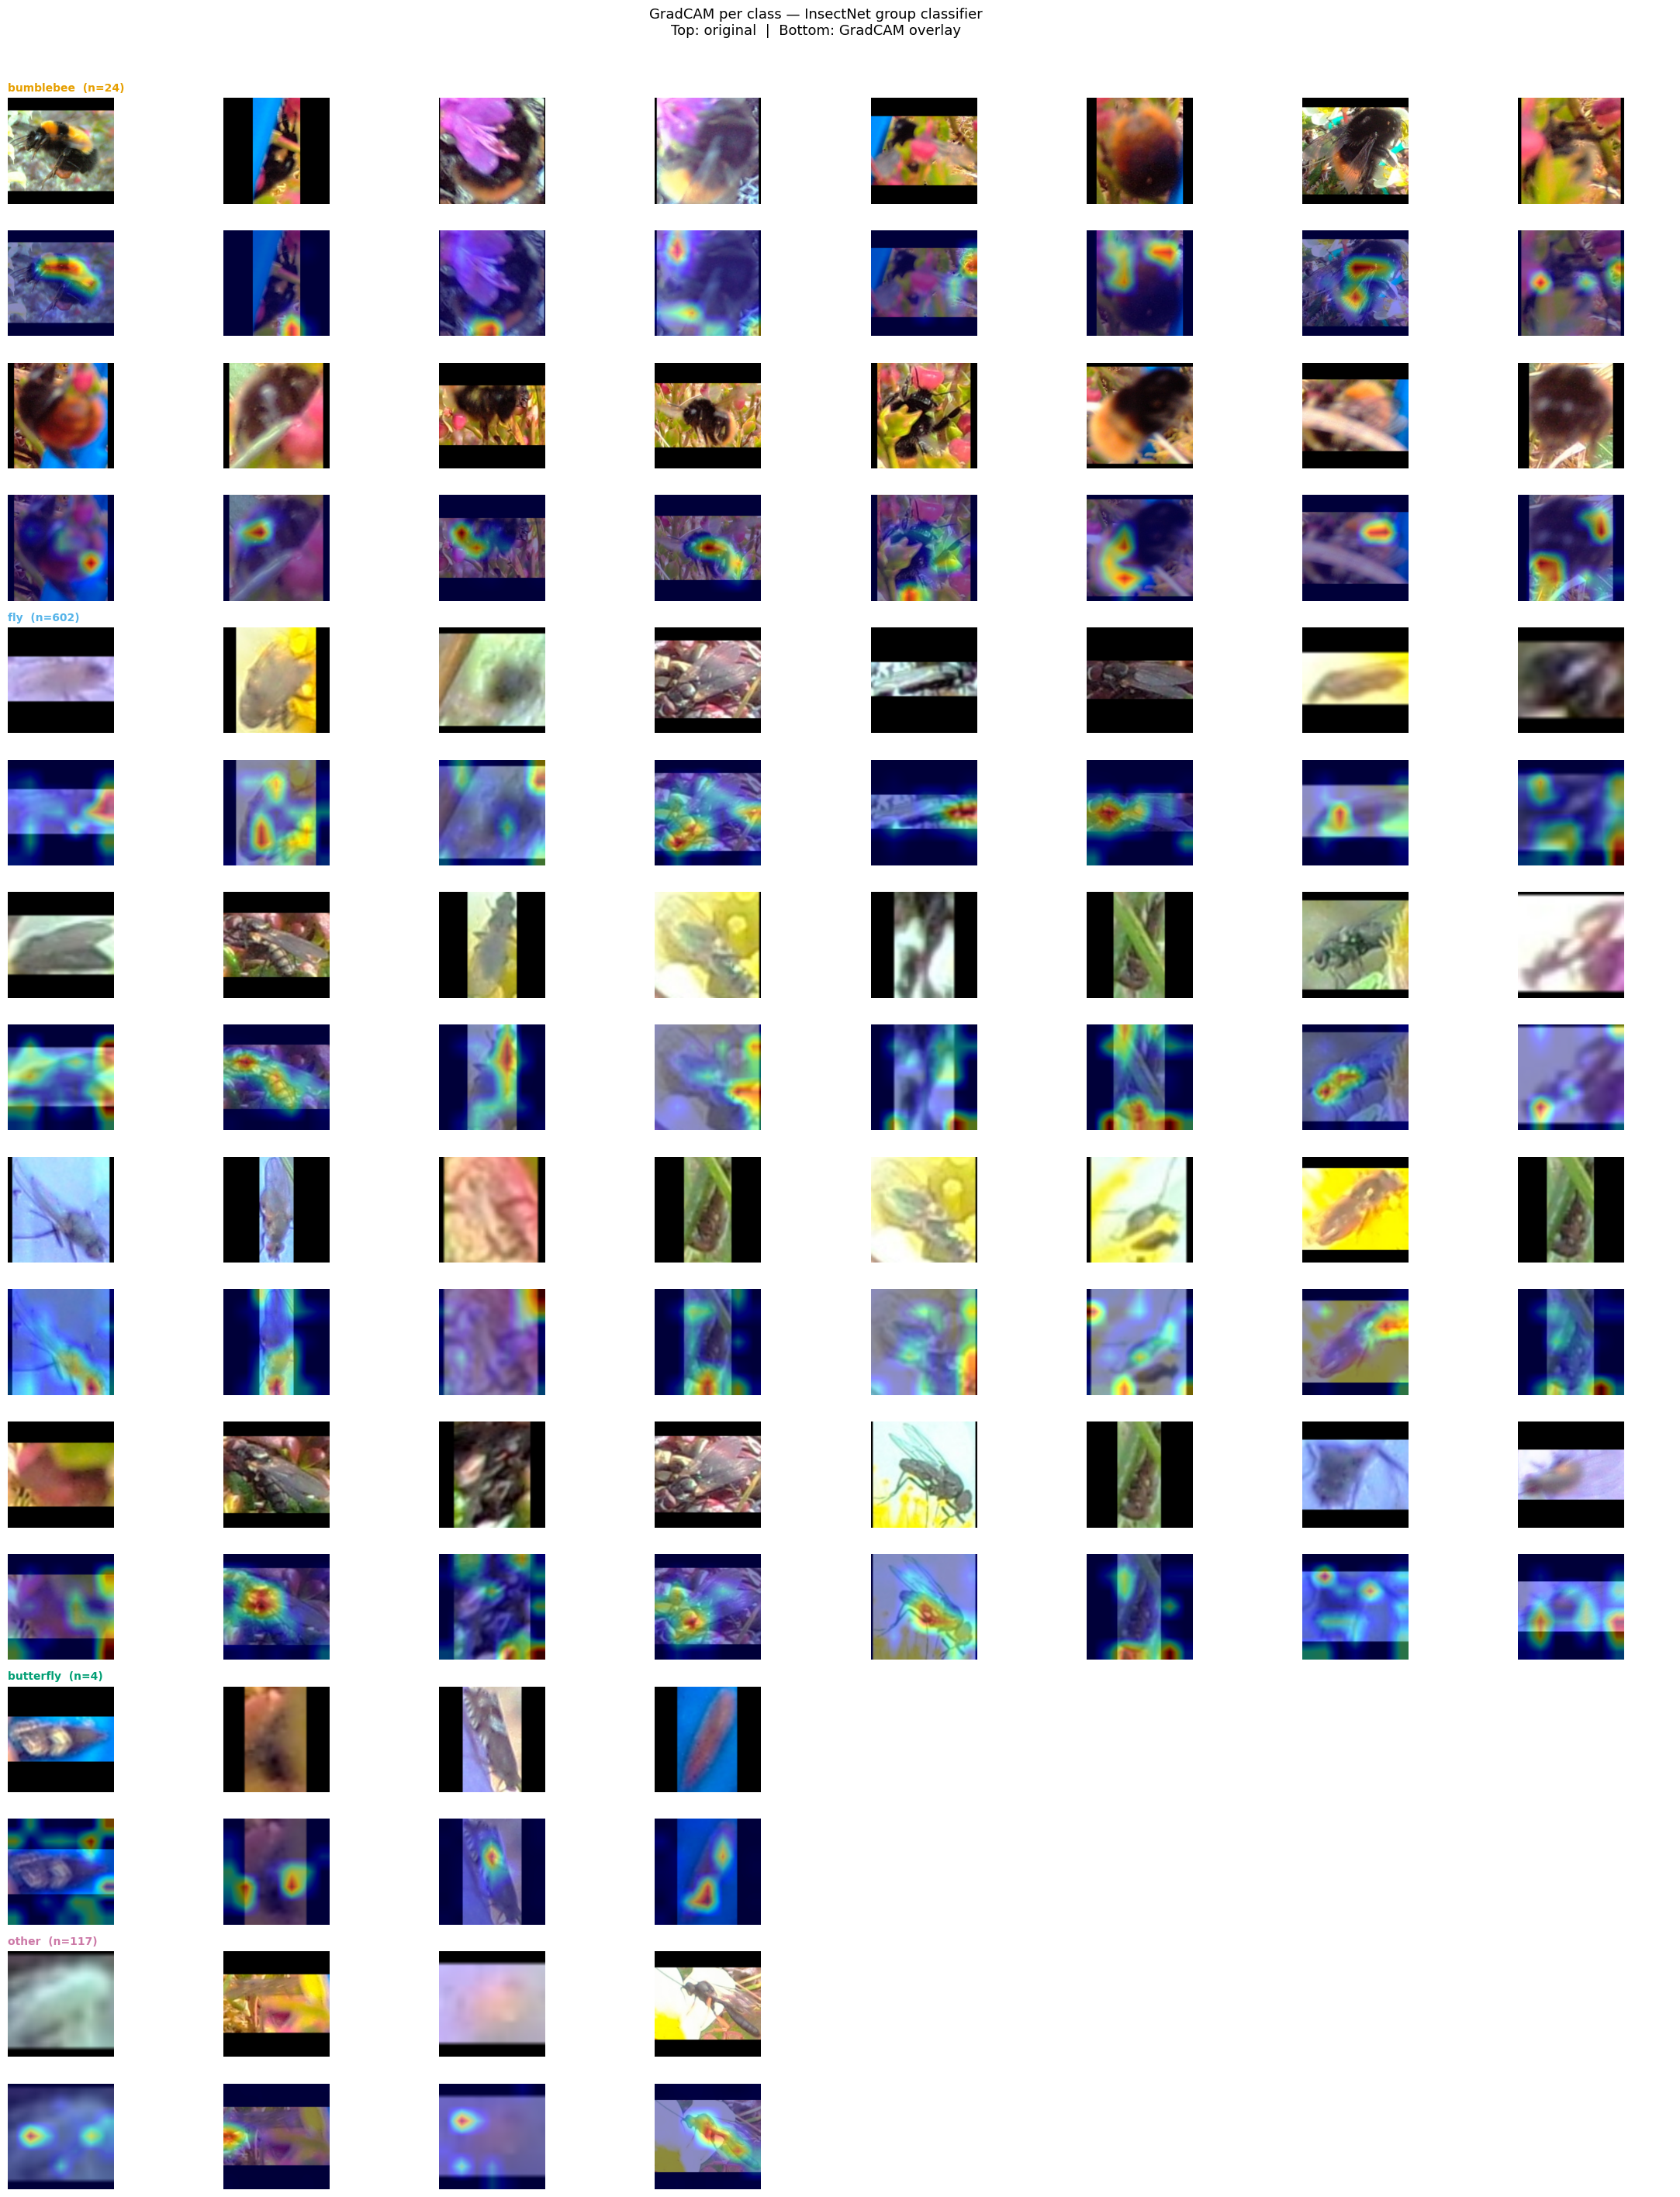

Saved -> /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/outputs/gradcam_all_classes.png


In [6]:
import math

N_PER_CLASS = {
    'fly':       32,   # 602 available
    'bumblebee': 16,   # 24 available
    'butterfly': 4,    # only 4 available
    'other':     4,
}
MAX_COLS = 8   # max images per row
ALPHA    = 0.45

gradcam = GradCAM(model, model.trunk_output.block4)

# Compute total rows needed: each chunk of 8 gets 2 rows (orig + cam)
total_rows = sum(math.ceil(N_PER_CLASS[c] / MAX_COLS) * 2 for c in CLASSES)
fig, axes = plt.subplots(total_rows, MAX_COLS,
                          figsize=(2.8 * MAX_COLS, 3.5 * total_rows / 2))
fig.suptitle('GradCAM per class — InsectNet group classifier\n'
             'Top: original  |  Bottom: GradCAM overlay', fontsize=13, y=1.01)

row_offset = 0
for cls_name in CLASSES:
    cls_idx = CLASSES.index(cls_name)
    n_show  = N_PER_CLASS[cls_name]
    samples = gt_crops[cls_name][:n_show]
    n       = len(samples)
    n_chunks = math.ceil(n_show / MAX_COLS)

    for chunk in range(n_chunks):
        orig_row = row_offset + chunk * 2
        cam_row  = orig_row + 1
        for col in range(MAX_COLS):
            sample_idx = chunk * MAX_COLS + col
            ax_o = axes[orig_row, col]
            ax_h = axes[cam_row,  col]
            if sample_idx >= n:
                ax_o.axis('off'); ax_h.axis('off'); continue

            pil = samples[sample_idx]
            lb  = np.array(letterbox(pil, IMG_SIZE))
            cam_map = gradcam(INF_TF(pil).unsqueeze(0).to(DEVICE), cls_idx)
            overlay = np.clip((1-ALPHA)*lb/255 + ALPHA*cm.jet(cam_map)[:,:,:3], 0, 1)

            ax_o.imshow(lb); ax_o.axis('off')
            ax_h.imshow(overlay); ax_h.axis('off')

            # Label on first image of first chunk only
            if chunk == 0 and col == 0:
                ax_o.set_title(f'{cls_name}  (n={len(gt_crops[cls_name])})',
                               fontsize=10, color=COLORS[cls_name],
                               fontweight='bold', loc='left')

    row_offset += n_chunks * 2

plt.tight_layout()
out = OUT_DIR / 'gradcam_all_classes.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')
gradcam.remove()


---
## 2. Robustness analysis — per-class recall

Recall = fraction of class X crops still predicted as class X under each distortion.

In [7]:
def jpeg_compress(quality):
    def _fn(img):
        buf = BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        return Image.open(buf).copy()
    return T.Lambda(_fn)

distortions = [
    ('Baseline',  None),
    ('Blur σ=1',  T.GaussianBlur(kernel_size=7,  sigma=1.0)),
    ('Blur σ=2',  T.GaussianBlur(kernel_size=11, sigma=2.0)),
    ('Blur σ=4',  T.GaussianBlur(kernel_size=15, sigma=4.0)),
    ('Dark ×0.7', T.Lambda(lambda img: TF.adjust_brightness(img, 0.7))),
    ('Dark ×0.5', T.Lambda(lambda img: TF.adjust_brightness(img, 0.5))),
    ('Dark ×0.3', T.Lambda(lambda img: TF.adjust_brightness(img, 0.3))),
    ('JPEG q=75', jpeg_compress(75)),
    ('JPEG q=50', jpeg_compress(50)),
    ('JPEG q=20', jpeg_compress(20)),
]

rob_results = {cls: {} for cls in CLASSES}
for label, dist in distortions:
    print(f'{label} ...', end=' ', flush=True)
    for cls_name in CLASSES:
        crops = gt_crops[cls_name]
        if not crops:
            rob_results[cls_name][label] = float('nan'); continue
        preds, _ = predict_pil_batch(crops, extra_tf=dist)
        rob_results[cls_name][label] = np.mean(preds == CLASSES.index(cls_name))
    print('done')

print('\nBaseline recall:')
for cls_name in CLASSES:
    print(f'  {cls_name:12}: {rob_results[cls_name]["Baseline"]:.3f}  (n={len(gt_crops[cls_name])})')

Baseline ... done
Blur σ=1 ... done
Blur σ=2 ... done
Blur σ=4 ... done
Dark ×0.7 ... done
Dark ×0.5 ... done
Dark ×0.3 ... done
JPEG q=75 ... done
JPEG q=50 ... done
JPEG q=20 ... done

Baseline recall:
  bumblebee   : 0.500  (n=24)
  fly         : 0.958  (n=602)
  butterfly   : 0.250  (n=4)
  other       : 0.034  (n=117)


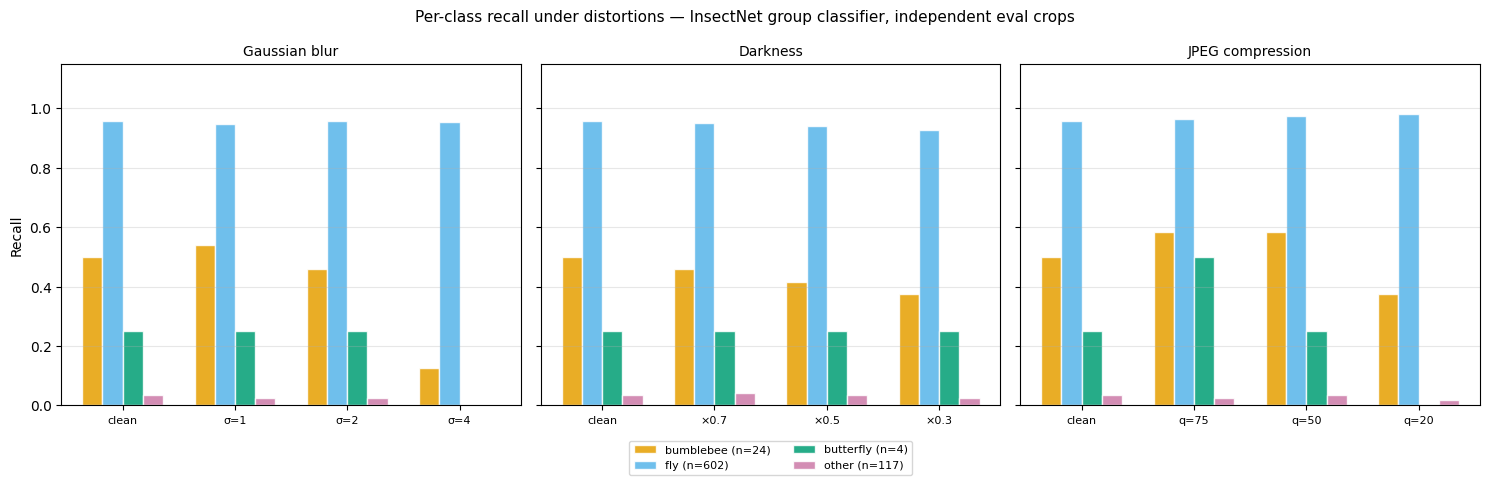

Saved → /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/outputs/robustness_all_classes.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Per-class recall under distortions — InsectNet group classifier, independent eval crops',
             fontsize=11)

groups = [
    ('Gaussian blur',    ['Baseline', 'Blur σ=1', 'Blur σ=2', 'Blur σ=4'],    ['clean', 'σ=1', 'σ=2', 'σ=4']),
    ('Darkness',         ['Baseline', 'Dark ×0.7', 'Dark ×0.5', 'Dark ×0.3'], ['clean', '×0.7', '×0.5', '×0.3']),
    ('JPEG compression', ['Baseline', 'JPEG q=75', 'JPEG q=50', 'JPEG q=20'], ['clean', 'q=75', 'q=50', 'q=20']),
]

x = np.arange(4)
bar_w   = 0.18
offsets = np.linspace(-(len(CLASSES)-1)/2, (len(CLASSES)-1)/2, len(CLASSES)) * bar_w

for ax, (title, keys, xticks) in zip(axes, groups):
    for i, cls_name in enumerate(CLASSES):
        vals = [rob_results[cls_name][k] for k in keys]
        n    = len(gt_crops[cls_name])
        ax.bar(x + offsets[i], vals, width=bar_w,
               color=COLORS[cls_name], alpha=0.85,
               label=f'{cls_name} (n={n})', edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(xticks, fontsize=8)
    ax.set_ylim(0, 1.15)
    if ax is axes[0]:
        ax.set_ylabel('Recall', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[1].legend(fontsize=8, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.22))
plt.tight_layout()
out = OUT_DIR / 'robustness_all_classes.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

---
## 3. Confidence calibration (ECE) — all classes

All GT crops pooled with correct labels. Reliability diagram + per-class accuracy breakdown.

In [9]:
print(f'Running inference on all {len(all_crops)} GT crops ...')
preds_all, confs_all = predict_pil_batch(all_crops)

max_conf = confs_all.max(axis=1)
correct  = (preds_all == all_labels).astype(float)

print(f'Overall accuracy: {correct.mean():.3f}')
print('Per-class accuracy:')
for cls_name in CLASSES:
    idx  = CLASSES.index(cls_name)
    mask = all_labels == idx
    if mask.sum() > 0:
        print(f'  {cls_name:12}: {correct[mask].mean():.3f}  (n={mask.sum()})')

N_BINS = 10
bins = np.linspace(0, 1, N_BINS + 1)
bin_acc  = np.zeros(N_BINS)
bin_conf = np.zeros(N_BINS)
bin_cnt  = np.zeros(N_BINS, dtype=int)
for i in range(N_BINS):
    mask = (max_conf >= bins[i]) & (max_conf < bins[i+1])
    if mask.sum() > 0:
        bin_acc[i]  = correct[mask].mean()
        bin_conf[i] = max_conf[mask].mean()
        bin_cnt[i]  = mask.sum()

ece = np.sum(np.abs(bin_acc - bin_conf) * bin_cnt) / len(all_labels)
print(f'\nECE = {ece:.4f}')

Running inference on all 747 GT crops ...
Overall accuracy: 0.795
Per-class accuracy:
  bumblebee   : 0.500  (n=24)
  fly         : 0.958  (n=602)
  butterfly   : 0.250  (n=4)
  other       : 0.034  (n=117)

ECE = 0.1132


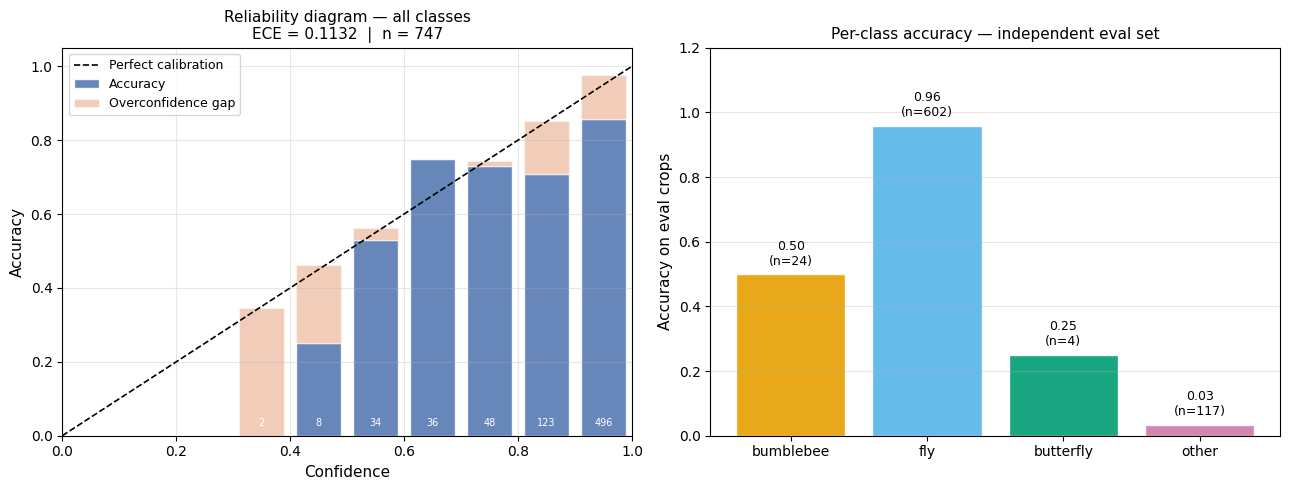

Saved → /Users/lianshi/Downloads/bachelor thesis/automated-ecological-image-analysis/ml_pipelines/notebooks/pollinator_detection/outputs/ece_all_classes.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bin_centres = (bins[:-1] + bins[1:]) / 2

# Reliability diagram
ax = axes[0]
ax.bar(bin_centres, bin_acc, width=0.08, alpha=0.85,
       label='Accuracy', color='#4C72B0', edgecolor='white')
ax.bar(bin_centres, np.maximum(bin_conf - bin_acc, 0), width=0.08,
       bottom=bin_acc, alpha=0.4, color='#DD8452',
       edgecolor='white', label='Overconfidence gap')
ax.plot([0,1],[0,1],'k--', lw=1.2, label='Perfect calibration')
ax.set_xlabel('Confidence', fontsize=11); ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(f'Reliability diagram — all classes\nECE = {ece:.4f}  |  n = {len(all_labels)}', fontsize=11)
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
for c, cnt in zip(bin_centres, bin_cnt):
    if cnt > 0:
        ax.text(c, 0.02, str(int(cnt)), ha='center', va='bottom', fontsize=7, color='white')

# Per-class accuracy bar chart
ax2 = axes[1]
cls_accs, cls_ns, cls_colors = [], [], []
for cls_name in CLASSES:
    mask = all_labels == CLASSES.index(cls_name)
    cls_accs.append(correct[mask].mean() if mask.sum() > 0 else 0)
    cls_ns.append(int(mask.sum()))
    cls_colors.append(COLORS[cls_name])

bars = ax2.bar(CLASSES, cls_accs, color=cls_colors, edgecolor='white', alpha=0.9)
for bar, acc, n in zip(bars, cls_accs, cls_ns):
    ax2.text(bar.get_x() + bar.get_width()/2, acc + 0.02,
             f'{acc:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel('Accuracy on eval crops', fontsize=11)
ax2.set_title('Per-class accuracy — independent eval set', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = OUT_DIR / 'ece_all_classes.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

--- 
## Summary

All outputs saved to `outputs/evaluation/crop_sensitivity_{timestamp}/`:

| Analysis | File |
|---|---|
| GradCAM (all classes) | `gradcam_all_classes.png` |
| Robustness (per class) | `robustness_all_classes.png` |
| ECE + per-class accuracy | `ece_all_classes.png` |
